# Phase 4 — Cost-Aware Decision Layer

**Project:** Aegis — Cost-Aware Real-Time Fraud Intelligence System
**Author:** Kashish Lalwani
**Course:** AMS 561, Spring 2026

## What this notebook does
Loads the Phase 3 Random Forest model, scores all 49,962 transactions to produce continuous
fraud probabilities, then converts those probabilities into one of three discrete operational
actions (APPROVE / FLAG / BLOCK) using cost-justified thresholds. Persists the final
decisioned dataset for downstream drift monitoring (Phase 5) and threshold optimization (Phase 6).

## Inputs
- `dbfs:/Volumes/workspace/default/raw_data/fraud_model` (Phase 3 trained Random Forest)
- `dbfs:/Volumes/workspace/default/raw_data/streaming_output` (Phase 2 enriched data, 49,962 × 13)

## Outputs
- `dbfs:/Volumes/workspace/default/raw_data/decision_output` (49,962 rows × 15 columns, with `fraud_probability` and `decision` added)
- `/tmp/aegis_decision_heatmap.png` (visual artifact, used as Figure 4 in the report)

## Why three tiers, not two
A binary fraud classifier collapses an asymmetric cost structure into a single threshold. In
this dataset:

| Outcome | Cost |
|---|---|
| Missed fraud | ~$1,500,000 |
| False alarm | ~$15 |
| Manual review | ~$5 |

The cost ratio between a missed fraud and a false alarm is roughly **100,000×**. A two-tier
policy at the default 0.5 cutoff treats both errors as equal, which is empirically wrong.
The three-tier policy below uses two thresholds (0.30 / 0.70) so that the uncertain middle
band is routed to human review paying $5 to avoid risking $1.5M.

## Headline results
- 48,401 auto-approved (96.87%)
- 1,389 flagged for review (2.78%)
- 172 auto-blocked (0.34%)
- **97.1% fraud catch rate** (67/69) before any analyst intervention
- Only 0.23% of legitimate transactions are auto-blocked

Step 1 - Setting Up the Notebook and Loading the Saved Model

In [0]:
# Loading the trained Random Forest model from DBFS
from pyspark.ml.classification import RandomForestClassificationModel

model_path = "dbfs:/Volumes/workspace/default/raw_data/fraud_model"
rf_model = RandomForestClassificationModel.load(model_path)

print("Model loaded successfully")
print(rf_model)

Model loaded successfully
RandomForestClassificationModel: uid=RandomForestClassifier_39e0cda61a52, numTrees=100, numClasses=2, numFeatures=7


Step 2 - Loading the Streaming Output as Input Data

In [0]:

input_path = "dbfs:/Volumes/workspace/default/raw_data/streaming_output"
input_df = spark.read.format("delta").load(input_path)

# Verifying it loaded correctly
print(f"Row count: {input_df.count()}")
print(f"Column count: {len(input_df.columns)}")
print(f"Columns: {input_df.columns}")

# Previewing a few rows
input_df.show(5)

Row count: 49962
Column count: 13
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'is_high_risk_type', 'balance_diff']
+-----+--------+---------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+-----------------+------------+
| step|    type|   amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|is_high_risk_type|balance_diff|
+-----+--------+---------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+-----------------+------------+
|396.0|CASH_OUT|118326.41| C944557061|     121796.0|       3469.59|C1487077526|    1182256.11|    1300582.52|      0|           0.0|                1|   118326.41|
|373.0| PAYMENT| 17068.83| C255803662|      20451.0|       3382.17| M499251811|           0.0|           0.0|    

Step 3: Reassembling Features into a Vector

In [0]:

from pyspark.ml.feature import VectorAssembler

feature_cols = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "is_high_risk_type",
    "balance_diff"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_df = assembler.transform(input_df)

# Verifying the features column was added
print(f"Columns now: {assembled_df.columns}")
assembled_df.select("amount", "is_high_risk_type", "balance_diff", "features").show(3, truncate=False)

Columns now: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'is_high_risk_type', 'balance_diff', 'features']
+---------+-----------------+------------+----------------------------------------------------------------+
|amount   |is_high_risk_type|balance_diff|features                                                        |
+---------+-----------------+------------+----------------------------------------------------------------+
|118326.41|1                |118326.41   |[118326.41,121796.0,3469.59,1182256.11,1300582.52,1.0,118326.41]|
|17068.83 |0                |17068.83    |[17068.83,20451.0,3382.17,0.0,0.0,0.0,17068.83]                 |
|369264.57|1                |124268.0    |[369264.57,124268.0,0.0,868843.17,1238107.74,1.0,124268.0]      |
+---------+-----------------+------------+----------------------------------------------------------------+
only showing top 3 rows


Step 4 - Generating Fraud Probability Scores

In [0]:

from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

# Applying the model — this adds rawPrediction, probability, and prediction columns
scored_df = rf_model.transform(assembled_df)

# Extracting the fraud probability (index 1 of the probability vector) into its own column
extract_fraud_prob = F.udf(lambda v: float(v[1]), DoubleType())
scored_df = scored_df.withColumn("fraud_probability", extract_fraud_prob("probability"))

# showing some probabilities alongside the actual labels
scored_df.select("amount", "is_high_risk_type", "isFraud", "fraud_probability") \
         .orderBy(F.desc("fraud_probability")) \
         .show(10, truncate=False)

+----------+-----------------+-------+------------------+
|amount    |is_high_risk_type|isFraud|fraud_probability |
+----------+-----------------+-------+------------------+
|2723017.17|1                |1      |0.9940825772123187|
|1289142.33|1                |1      |0.9940825772123187|
|2755588.11|1                |1      |0.9940825772123187|
|1070857.97|1                |1      |0.9940825772123187|
|8924971.59|1                |1      |0.9940825772123187|
|1644749.94|1                |1      |0.9940825772123187|
|1892137.66|1                |1      |0.9940825772123187|
|2772043.9 |1                |1      |0.9940825772123187|
|2060748.45|1                |1      |0.9940825772123187|
|1501297.88|1                |1      |0.9940825772123187|
+----------+-----------------+-------+------------------+
only showing top 10 rows


Step 5 - Defining Cost-Based Thresholds

In [0]:

# Cost assumptions (in USD)
COST_MISSED_FRAUD = 1_500_000   # average loss when a fraud goes through
COST_FALSE_ALARM  = 15          # customer-service cost when a real customer is blocked
COST_MANUAL_REVIEW = 5          # analyst time cost when a transaction is flagged

# Decision thresholds (probability cutoffs)
APPROVE_THRESHOLD = 0.30   # fraud_probability < 0.30 -> approve
BLOCK_THRESHOLD   = 0.70   # fraud_probability >= 0.70 -> block
                            # 0.30 <= fraud_probability < 0.70 -> flag

# Printing for reproducibility / report
print("=== Cost-Aware Decision Thresholds ===")
print(f"Cost of missed fraud (FN):    ${COST_MISSED_FRAUD:,}")
print(f"Cost of false alarm (FP):     ${COST_FALSE_ALARM:,}")
print(f"Cost of manual review:        ${COST_MANUAL_REVIEW:,}")
print(f"Cost ratio (FN / FP):         {COST_MISSED_FRAUD // COST_FALSE_ALARM:,}x")
print()
print(f"Approve if fraud_probability <  {APPROVE_THRESHOLD}")
print(f"Block   if fraud_probability >= {BLOCK_THRESHOLD}")
print(f"Flag    if {APPROVE_THRESHOLD} <= fraud_probability < {BLOCK_THRESHOLD}")

=== Cost-Aware Decision Thresholds ===
Cost of missed fraud (FN):    $1,500,000
Cost of false alarm (FP):     $15
Cost of manual review:        $5
Cost ratio (FN / FP):         100,000x

Approve if fraud_probability <  0.3
Block   if fraud_probability >= 0.7
Flag    if 0.3 <= fraud_probability < 0.7


Step 6 - Applying Thresholds to Assign Decisions

In [0]:

from pyspark.sql import functions as F

decision_df = scored_df.withColumn(
    "decision",
    F.when(F.col("fraud_probability") < APPROVE_THRESHOLD, "APPROVE")
     .when(F.col("fraud_probability") < BLOCK_THRESHOLD, "FLAG")
     .otherwise("BLOCK")
)

# a few rows showing fraud probability, the decision, and the true label
decision_df.select("amount", "is_high_risk_type", "fraud_probability", "decision", "isFraud") \
           .orderBy(F.desc("fraud_probability")) \
           .show(15, truncate=False)

+----------+-----------------+------------------+--------+-------+
|amount    |is_high_risk_type|fraud_probability |decision|isFraud|
+----------+-----------------+------------------+--------+-------+
|1289142.33|1                |0.9940825772123187|BLOCK   |1      |
|1070857.97|1                |0.9940825772123187|BLOCK   |1      |
|2723017.17|1                |0.9940825772123187|BLOCK   |1      |
|2755588.11|1                |0.9940825772123187|BLOCK   |1      |
|8924971.59|1                |0.9940825772123187|BLOCK   |1      |
|1644749.94|1                |0.9940825772123187|BLOCK   |1      |
|1892137.66|1                |0.9940825772123187|BLOCK   |1      |
|2772043.9 |1                |0.9940825772123187|BLOCK   |1      |
|2060748.45|1                |0.9940825772123187|BLOCK   |1      |
|1501297.88|1                |0.9940825772123187|BLOCK   |1      |
|621569.61 |1                |0.9939322937646548|BLOCK   |1      |
|591032.52 |1                |0.9939322937646548|BLOCK   |1   

Step 7 - Summary Count and Saving Final Delta Table

In [0]:

from pyspark.sql import functions as F

# 1. Summary count by decision 
print("=== Decision Summary ===")
decision_df.groupBy("decision").count().orderBy(F.desc("count")).show()

# 2. Cross-tabulation: decision vs. true label 
print("=== Decision vs. isFraud (cross-tabulation) ===")
decision_df.crosstab("decision", "isFraud").show()

# 3. Save as Delta (drop vector columns first for cleanliness) 
output_path = "dbfs:/Volumes/workspace/default/raw_data/decision_output"

final_df = decision_df.drop("features", "rawPrediction", "probability", "prediction")

final_df.write.format("delta").mode("overwrite").save(output_path)
print(f"Saved final decision table to: {output_path}")

# 4. Verifying by reading it back 
verify_df = spark.read.format("delta").load(output_path)
print(f"Verification — row count: {verify_df.count()}")
print(f"Verification — columns:   {verify_df.columns}")

=== Decision Summary ===
+--------+-----+
|decision|count|
+--------+-----+
| APPROVE|48401|
|    FLAG| 1389|
|   BLOCK|  172|
+--------+-----+

=== Decision vs. isFraud (cross-tabulation) ===
+----------------+-----+---+
|decision_isFraud|    0|  1|
+----------------+-----+---+
|            FLAG| 1378| 11|
|           BLOCK|  116| 56|
|         APPROVE|48399|  2|
+----------------+-----+---+

Saved final decision table to: dbfs:/Volumes/workspace/default/raw_data/decision_output
Verification — row count: 49962
Verification — columns:   ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'is_high_risk_type', 'balance_diff', 'fraud_probability', 'decision']


Phase 4 Add-On — Step 1: Loading the Decision Table and Build the Counts

In [0]:
# Phase 4 Add-On : Load decision table and build the cross-tab
from pyspark.sql import functions as F

# Reloading the saved decision table (in case the notebook was restarted)
output_path = "dbfs:/Volumes/workspace/default/raw_data/decision_output"
decision_df = spark.read.format("delta").load(output_path)

# Computing the 2x3 cross-tabulation in Spark
crosstab_spark = decision_df.crosstab("isFraud", "decision")

# Converting the small result to pandas for plotting
crosstab_pd = crosstab_spark.toPandas()

# Setting isFraud column as the index (so it labels the rows) and reorder columns logically
crosstab_pd = crosstab_pd.set_index("isFraud_decision")
crosstab_pd = crosstab_pd[["APPROVE", "FLAG", "BLOCK"]]

# Verifying the numbers
print("Cross-tabulation (rows = isFraud, cols = decision):")
print(crosstab_pd)

Cross-tabulation (rows = isFraud, cols = decision):
                  APPROVE  FLAG  BLOCK
isFraud_decision                      
0                   48399  1378    116
1                       2    11     56


Phase 4 Add-On — Step 2: Draw the Polished Annotated Heatmap

Figure saved to: /tmp/aegis_decision_heatmap.png


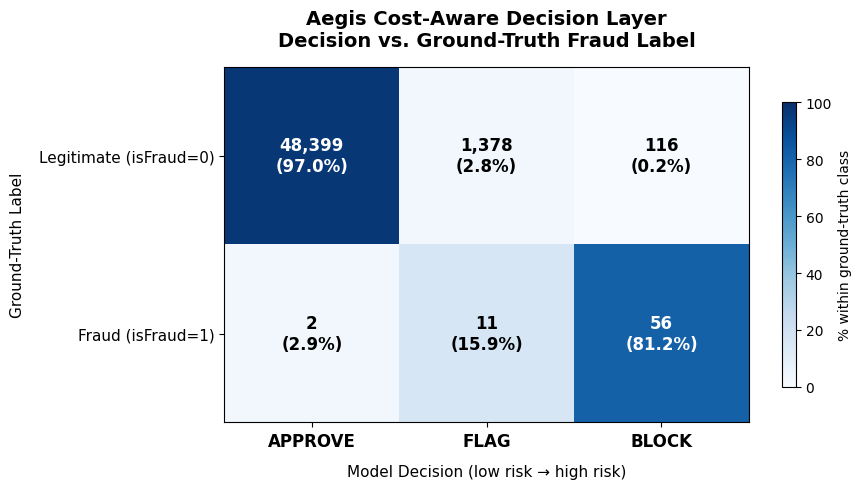

In [0]:
# Phase 4 Add-On Step 2: Polished annotated decision heatmap
import matplotlib.pyplot as plt
import numpy as np

# Preparing the data 
counts = crosstab_pd.values                          # 2x3 matrix of raw counts
row_totals = counts.sum(axis=1, keepdims=True)       # row totals (per fraud class)
percentages = counts / row_totals * 100              # row-normalized percentages

# Human-readable labels
row_labels = ["Legitimate (isFraud=0)", "Fraud (isFraud=1)"]
col_labels = ["APPROVE", "FLAG", "BLOCK"]

# --- Drawing the heatmap ---
fig, ax = plt.subplots(figsize=(9, 5))
heatmap = ax.imshow(percentages, cmap="Blues", aspect="auto", vmin=0, vmax=100)

# Ticking labels
ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=12, fontweight="bold")
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=11)

# Title and axis labels
ax.set_title(
    "Aegis Cost-Aware Decision Layer\nDecision vs. Ground-Truth Fraud Label",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Model Decision (low risk → high risk)", fontsize=11, labelpad=10)
ax.set_ylabel("Ground-Truth Label", fontsize=11, labelpad=10)

# Annotating each cell with count and row-percentage
for i in range(counts.shape[0]):
    for j in range(counts.shape[1]):
        count = counts[i, j]
        pct = percentages[i, j]
        # Choose text color: dark cells need white text for readability
        text_color = "white" if pct > 50 else "black"
        ax.text(j, i, f"{count:,}\n({pct:.1f}%)",
                ha="center", va="center",
                color=text_color, fontsize=12, fontweight="bold")

# Color bar
cbar = plt.colorbar(heatmap, ax=ax, shrink=0.8)
cbar.set_label("% within ground-truth class", fontsize=10)

plt.tight_layout()

# Saving figure for the report
fig_path = "/tmp/aegis_decision_heatmap.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")

plt.show()

## Summary

- **Loaded** the Phase 3 Random Forest model and applied it to all 49,962 transactions
- **Extracted** continuous fraud probabilities via a UDF on the `probability` vector column
- **Defined** a cost matrix ($1.5M / $15 / $5) and two cost-justified thresholds (0.30 / 0.70)
- **Decisioned** every transaction into APPROVE (48,401 / 96.87%), FLAG (1,389 / 2.78%), or BLOCK (172 / 0.34%)
- **Caught** 67 of 69 frauds (97.1%) before any analyst intervention; only 2 missed
- **Auto-blocked** only 116 of 49,893 legitimate transactions (0.23%)
- **Saved** the decisioned table to DBFS and rendered the cost-aware decision heatmap

**Saved to:**
- `dbfs:/Volumes/workspace/default/raw_data/decision_output` (Delta table, 49,962 × 15)
- `/tmp/aegis_decision_heatmap.png` (Figure 4 in the report)

**Catch-rate definition note:** the 97.1% figure assumes the FLAG queue is processed by a human analyst who would catch the 11 flagged frauds. Under a stricter definition that counts only auto-BLOCK as a catch, the rate at t=0.70 is 56/69 = 81.2%. Both are correct under their respective operational assumptions. Phase 6 returns to this distinction when it stress-tests the threshold.

**Next:** Phase 5 (`05_drift_detection.ipynb`) reads this decisioned table, splits it temporally, and runs PSI + Kolmogorov–Smirnov tests on every feature to detect distributional shift. Phase 6 (`06_threshold_optimization.ipynb`) uses the same table to defend the 0.70 threshold choice via a 19-point cost sweep.